In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import os

base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
file_path = os.path.join(base_dir, "data", "processed", "financial_cleaned.csv")

df = pd.read_csv(file_path)
print("✅ Loaded:", df.shape)
df.head()

✅ Loaded: (540, 6)


,year_month,product,region,revenue,cost,profit
0,2014-01,Furniture,Central,76.728,130.4376,-53.7096
1,2014-01,Furniture,East,9.940,6.8586,3.0814
2,2014-01,Furniture,South,2625.760,1858.0568,767.7032
3,2014-01,Office Supplies,Central,324.282,401.8054,-77.5234
4,2014-01,Office Supplies,East,19.536,14.6520,4.8840


In [2]:
# Prophet requires columns named 'ds' (date) and 'y' (value)
monthly = df.groupby("year_month")["revenue"].sum().reset_index()
monthly.columns = ["ds", "y"]
monthly["ds"] = pd.to_datetime(monthly["ds"])

print("✅ Data prepared:", monthly.shape)
monthly.head()

✅ Data prepared: (48, 2)


,ds,y
0,2014-01-01,4923.616
1,2014-02-01,3610.402
2,2014-03-01,8048.773
3,2014-04-01,16040.811
4,2014-05-01,9288.864


In [4]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

model.fit(monthly)
print("")

20:19:33 - cmdstanpy - INFO - Chain [1] start processing
20:19:33 - cmdstanpy - INFO - Chain [1] done processing


In [5]:
future = model.make_future_dataframe(periods=12, freq="MS")
forecast = model.predict(future)

print(" Forecasted ")
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(12)

 Forecasted 


,ds,yhat,yhat_lower,yhat_upper
48,2018-01-01,14594.724642,9278.971400,19988.900355
49,2018-02-01,13613.482301,8238.695397,18623.517117
50,2018-03-01,20242.673651,14785.279532,25483.530652
51,2018-04-01,22035.867006,16556.231275,26964.151099
52,2018-05-01,20682.941425,15517.157965,26283.623381
53,2018-06-01,22959.518466,17771.400841,28597.669592
54,2018-07-01,20663.102681,15372.285072,25904.357609
55,2018-08-01,22613.481831,17238.374146,27984.183928
56,2018-09-01,36930.323017,31830.723393,42358.680382
57,2018-10-01,25775.845186,20272.431974,30963.939036


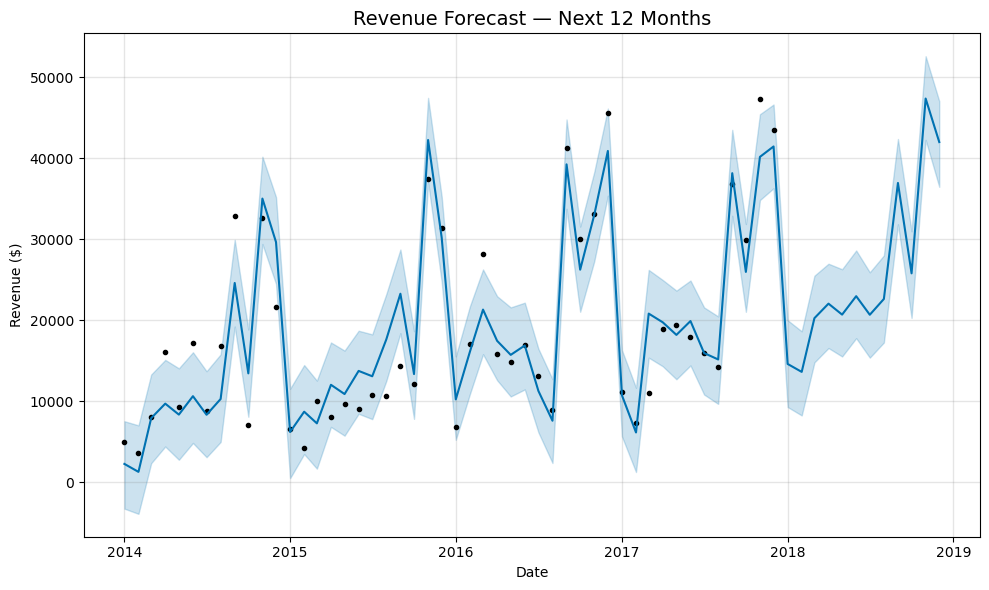

In [7]:
fig1 = model.plot(forecast)
plt.title("Revenue Forecast — Next 12 Months", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.savefig("../reports/revenue_forecast.png")
plt.show()


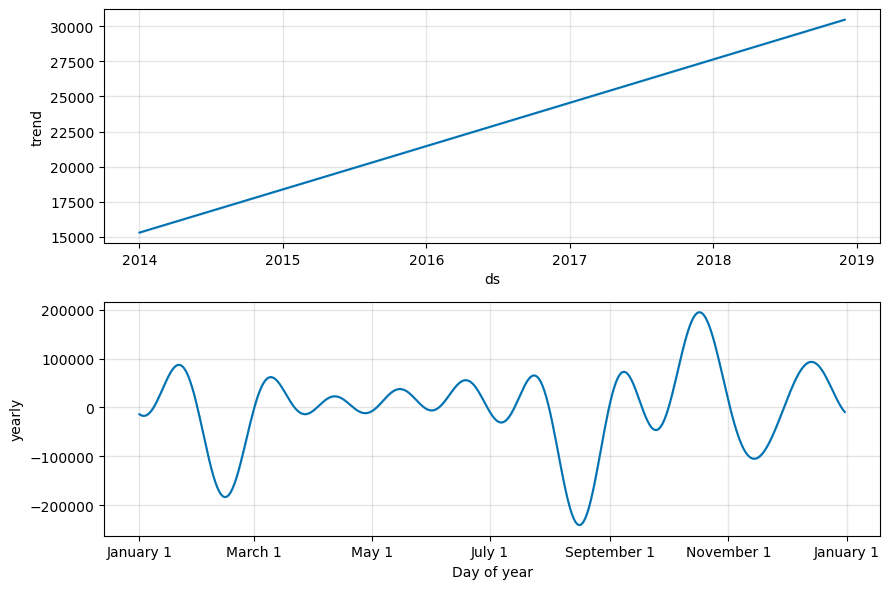

In [8]:
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.savefig("../reports/forecast_components.png")
plt.show()


In [9]:
forecast_future = forecast[forecast["ds"] > monthly["ds"].max()][[
    "ds", "yhat", "yhat_lower", "yhat_upper"
]].copy()

forecast_future.columns = ["Month", "Predicted Revenue", "Lower Bound", "Upper Bound"]
forecast_future["Predicted Revenue"] = forecast_future["Predicted Revenue"].round(2)
forecast_future["Lower Bound"] = forecast_future["Lower Bound"].round(2)
forecast_future["Upper Bound"] = forecast_future["Upper Bound"].round(2)

print("12-Month Revenue Forecast:")
forecast_future

12-Month Revenue Forecast:


,Month,Predicted Revenue,Lower Bound,Upper Bound
48,2018-01-01,14594.72,9278.97,19988.90
49,2018-02-01,13613.48,8238.70,18623.52
50,2018-03-01,20242.67,14785.28,25483.53
51,2018-04-01,22035.87,16556.23,26964.15
52,2018-05-01,20682.94,15517.16,26283.62
53,2018-06-01,22959.52,17771.40,28597.67
54,2018-07-01,20663.10,15372.29,25904.36
55,2018-08-01,22613.48,17238.37,27984.18
56,2018-09-01,36930.32,31830.72,42358.68
57,2018-10-01,25775.85,20272.43,30963.94


In [11]:
# Export forecast to CSV
forecast_export = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
forecast_export.columns = ["date", "predicted_revenue", "lower_bound", "upper_bound"]
forecast_export["date"] = forecast_export["date"].dt.strftime("%Y-%m")

output = os.path.join(base_dir, "data", "processed", "revenue_forecast.csv")
forecast_export.to_csv(output, index=False)

